# Jane Street Market Forecasting: `train.parquet` EDA

This notebook is for local learning, not competition submission. It focuses on understanding the large partitioned training parquet without loading all 12GB into memory at once.

Initial facts from a narrow scan:

- `train.parquet` has 10 partitions, 47,127,338 rows, and 92 columns.
- The time span is `date_id` 0 to 1698 and `time_id` 0 to 967.
- There are 39 observed `symbol_id` values, with more symbols appearing in later partitions.
- The scoring target is `responder_6`; it is clipped to [-5, 5], has mean about -0.0021, median about -0.0256, and weighted mean about -0.0029.
- Missingness is structured: some feature groups share identical null rates, so imputation should likely respect feature families rather than treat every column independently.

## Setup

If these packages are missing in your notebook kernel, run the install cell once. Polars is used because the full train set is large and stored as partitioned parquet.

In [2]:
# Uncomment and run once if your kernel does not already have these packages.
# !pip install polars pyarrow pandas matplotlib seaborn

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pl.Config.set_tbl_cols(120)
pl.Config.set_tbl_rows(30)

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "jane-street-market-forecasting":
    PROJECT_DIR = PROJECT_DIR / "jane-street-market-forecasting"

DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "train.parquet"
TRAIN_GLOB = str(TRAIN_DIR / "partition_id=*" / "*.parquet")

FEATURE_COLS = [f"feature_{i:02d}" for i in range(79)]
RESPONDER_COLS = [f"responder_{i}" for i in range(9)]
ID_COLS = ["date_id", "time_id", "symbol_id", "weight"]
TARGET = "responder_6"

FEATURES_META = DATA_DIR / "features.csv"
RESPONDERS_META = DATA_DIR / "responders.csv"

print(DATA_DIR)
print(TRAIN_DIR.exists(), FEATURES_META.exists(), RESPONDERS_META.exists())

/Users/zhangyue/Workspace/github/learning-toy-examples/jane-street-market-forecasting/data
True True True


## Parquet Layout And Schema

The training data is a directory of 10 parquet partitions. Inspecting file metadata is fast and does not read the full dataset.

In [4]:
import pyarrow.parquet as pq

parquet_files = sorted(TRAIN_DIR.glob("partition_id=*/part-*.parquet"))
metadata_rows = []

for file_path in parquet_files:
    parquet_file = pq.ParquetFile(file_path)
    metadata_rows.append(
        {
            "partition": file_path.parent.name,
            "file": file_path.name,
            "rows": parquet_file.metadata.num_rows,
            "row_groups": parquet_file.metadata.num_row_groups,
            "columns": parquet_file.metadata.num_columns,
            "size_gb": file_path.stat().st_size / 1024**3,
        }
    )

partition_meta = pd.DataFrame(metadata_rows)
display(partition_meta)
print(f"Total rows from parquet metadata: {partition_meta['rows'].sum():,}")
print(f"Total parquet file size: {partition_meta['size_gb'].sum():.2f} GB")

schema = pq.ParquetFile(parquet_files[0]).schema_arrow
schema_df = pd.DataFrame(
    [{"column": field.name, "dtype": str(field.type)} for field in schema]
)
display(schema_df.head(100))

,partition,file,rows,row_groups,columns,size_gb
0,partition_id=0,part-0.parquet,1944210,7,92,0.438040
1,partition_id=1,part-0.parquet,2804247,10,92,0.663151
2,partition_id=2,part-0.parquet,3036873,11,92,0.740209
3,partition_id=3,part-0.parquet,4016784,15,92,0.980117
4,partition_id=4,part-0.parquet,5022952,19,92,1.231832
5,partition_id=5,part-0.parquet,5348200,20,92,1.310471
6,partition_id=6,part-0.parquet,6203912,23,92,1.518692
7,partition_id=7,part-0.parquet,6335560,24,92,1.547692
8,partition_id=8,part-0.parquet,6140024,23,92,1.497806
9,partition_id=9,part-0.parquet,6274576,23,92,1.526983


Total rows from parquet metadata: 47,127,338
Total parquet file size: 11.45 GB


,column,dtype
0,date_id,int16
1,time_id,int16
2,symbol_id,int8
3,weight,float
4,feature_00,float
5,feature_01,float
6,feature_02,float
7,feature_03,float
8,feature_04,float
9,feature_05,float


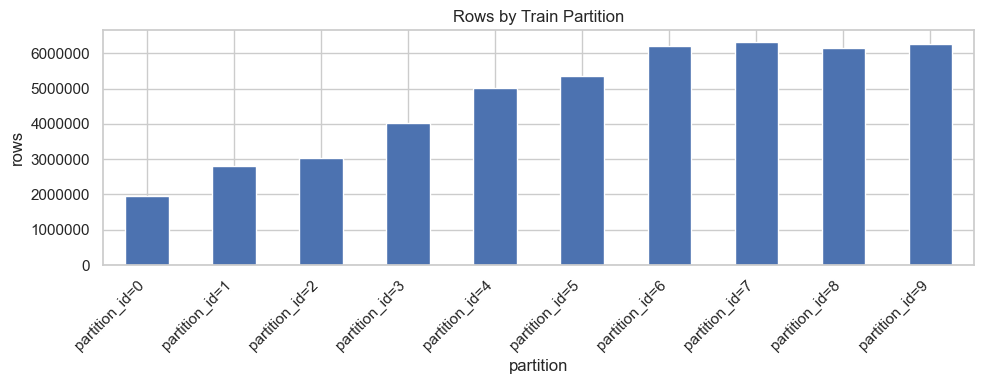

In [5]:
ax = partition_meta.plot(
    x="partition",
    y="rows",
    kind="bar",
    figsize=(10, 4),
    legend=False,
    title="Rows by Train Partition",
)
ax.set_ylabel("rows")
ax.ticklabel_format(axis="y", style="plain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## High-Level Dataset Summary

This cell scans a narrow set of columns to get global counts, ranges, target distribution summaries, and the weighted target mean used by the competition metric.

In [6]:
train_lf = pl.scan_parquet(TRAIN_GLOB)

summary = train_lf.select(
    [
        pl.len().alias("rows"),
        pl.col("date_id").min().alias("min_date_id"),
        pl.col("date_id").max().alias("max_date_id"),
        pl.col("time_id").min().alias("min_time_id"),
        pl.col("time_id").max().alias("max_time_id"),
        pl.col("symbol_id").n_unique().alias("n_symbols"),
        pl.col("weight").mean().alias("weight_mean"),
        pl.col("weight").sum().alias("weight_sum"),
        pl.col("weight").quantile(0.5).alias("weight_median"),
        pl.col(TARGET).mean().alias("target_mean"),
        pl.col(TARGET).std().alias("target_std"),
        pl.col(TARGET).min().alias("target_min"),
        pl.col(TARGET).quantile(0.01).alias("target_p01"),
        pl.col(TARGET).quantile(0.5).alias("target_p50"),
        pl.col(TARGET).quantile(0.99).alias("target_p99"),
        pl.col(TARGET).max().alias("target_max"),
        ((pl.col("weight") * pl.col(TARGET)).sum() / pl.col("weight").sum()).alias("target_weighted_mean"),
    ]
).collect()

summary.to_pandas().T.rename(columns={0: "value"})

,value
rows,4.712734e+07
min_date_id,0.000000e+00
max_date_id,1.698000e+03
min_time_id,0.000000e+00
max_time_id,9.670000e+02
n_symbols,3.900000e+01
weight_mean,2.009445e+00
weight_sum,9.469981e+07
weight_median,1.749686e+00
target_mean,-2.140649e-03


## Target And Weight Distributions

For plots, use a deterministic date-thinned sample. This preserves chronological structure better than taking only the first rows, while keeping the local notebook responsive.

In [7]:
SAMPLE_DATE_MOD = 20

sample_cols = ["date_id", "time_id", "symbol_id", "weight", *FEATURE_COLS, *RESPONDER_COLS]
sample = (
    train_lf
    .filter(pl.col("date_id") % SAMPLE_DATE_MOD == 0)
    .select(sample_cols)
    .collect()
)

sample_pd = sample.to_pandas()
print(sample.shape)
sample_pd[["date_id", "time_id", "symbol_id", "weight", TARGET]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

(2332423, 92)


,date_id,time_id,symbol_id,weight,responder_6
count,2.332423e+06,2.332423e+06,2.332423e+06,2.332423e+06,2.332423e+06
mean,9.982091e+02,4.687943e+02,1.811262e+01,2.014051e+00,-7.760854e-03
std,4.424462e+02,2.725631e+02,1.129069e+01,1.133095e+00,8.894597e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,1.922675e-01,-5.000000e+00
1%,4.000000e+01,9.000000e+00,0.000000e+00,4.537653e-01,-2.512571e+00
5%,2.000000e+02,4.600000e+01,1.000000e+00,6.914008e-01,-1.286937e+00
50%,1.060000e+03,4.670000e+02,1.700000e+01,1.734815e+00,-3.005238e-02
95%,1.620000e+03,9.030000e+02,3.700000e+01,4.289841e+00,1.367460e+00
99%,1.680000e+03,9.550000e+02,3.800000e+01,5.724522e+00,2.889304e+00
max,1.680000e+03,9.670000e+02,3.800000e+01,9.309741e+00,5.000000e+00


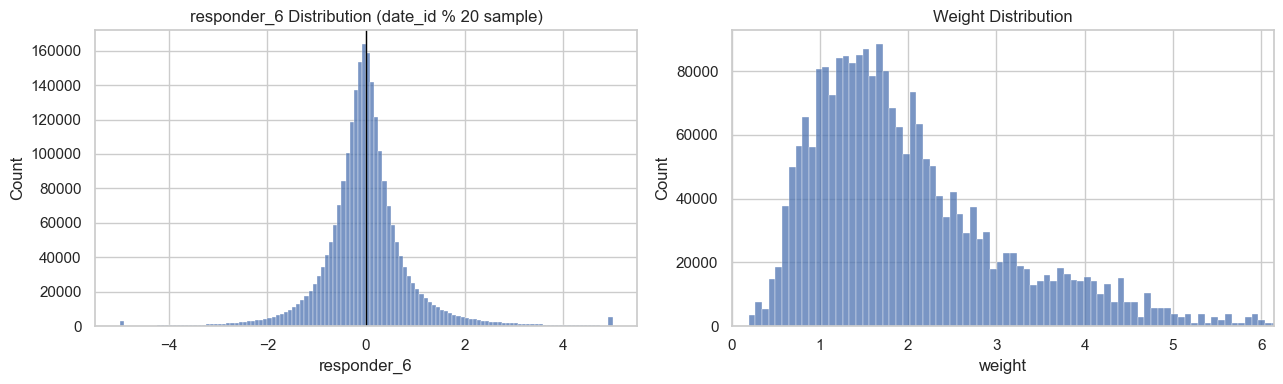

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(sample_pd[TARGET], bins=120, ax=axes[0])
axes[0].set_title(f"{TARGET} Distribution (date_id % {SAMPLE_DATE_MOD} sample)")
axes[0].axvline(0, color="black", linewidth=1)

sns.histplot(sample_pd["weight"], bins=120, ax=axes[1])
axes[1].set_title("Weight Distribution")
axes[1].set_xlim(0, sample_pd["weight"].quantile(0.995))

plt.tight_layout()

## Time Coverage And Drift

The partitions map cleanly to contiguous `date_id` ranges. Row counts and symbol coverage increase over time, so validation should be chronological rather than random.

In [9]:
partition_summaries = []

for partition_dir in sorted(TRAIN_DIR.glob("partition_id=*")):
    part = (
        pl.scan_parquet(str(partition_dir / "*.parquet"))
        .select(
            [
                pl.len().alias("rows"),
                pl.col("date_id").min().alias("min_date_id"),
                pl.col("date_id").max().alias("max_date_id"),
                pl.col("symbol_id").n_unique().alias("n_symbols"),
                pl.col(TARGET).mean().alias("target_mean"),
                pl.col(TARGET).std().alias("target_std"),
                pl.col("weight").mean().alias("weight_mean"),
            ]
        )
        .collect()
        .with_columns(pl.lit(partition_dir.name).alias("partition"))
        .select(["partition", "rows", "min_date_id", "max_date_id", "n_symbols", "target_mean", "target_std", "weight_mean"])
    )
    partition_summaries.append(part)

partition_summary = pl.concat(partition_summaries).to_pandas()
display(partition_summary)

,partition,rows,min_date_id,max_date_id,n_symbols,target_mean,target_std,weight_mean
0,partition_id=0,1944210,0,169,20,0.001488,0.870577,1.973282
1,partition_id=1,2804247,170,339,20,-0.006968,0.900644,1.866079
2,partition_id=2,3036873,340,509,29,-0.008083,0.940158,1.717335
3,partition_id=3,4016784,510,679,29,0.002036,1.008232,1.534328
4,partition_id=4,5022952,680,849,33,0.000059,0.943819,1.652586
5,partition_id=5,5348200,850,1019,36,-0.006323,0.900914,2.111238
6,partition_id=6,6203912,1020,1189,39,-0.004675,0.882888,1.739963
7,partition_id=7,6335560,1190,1359,39,0.001600,0.830640,1.997698
8,partition_id=8,6140024,1360,1529,39,0.001341,0.867378,2.669700
9,partition_id=9,6274576,1530,1698,39,-0.003780,0.814143,2.361383


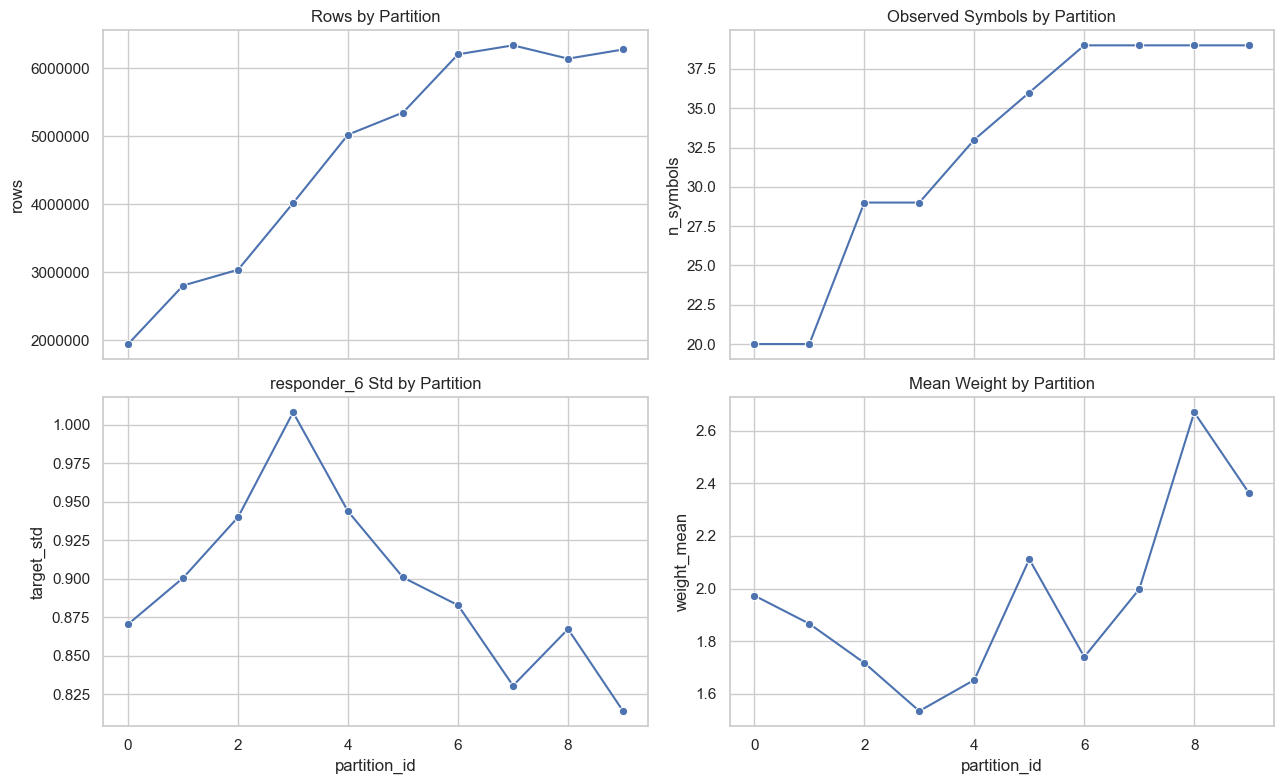

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

plot_df = partition_summary.copy()
plot_df["partition_id"] = plot_df["partition"].str.extract(r"(\d+)").astype(int)

sns.lineplot(data=plot_df, x="partition_id", y="rows", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Rows by Partition")
axes[0, 0].ticklabel_format(axis="y", style="plain")

sns.lineplot(data=plot_df, x="partition_id", y="n_symbols", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Observed Symbols by Partition")

sns.lineplot(data=plot_df, x="partition_id", y="target_std", marker="o", ax=axes[1, 0])
axes[1, 0].set_title(f"{TARGET} Std by Partition")

sns.lineplot(data=plot_df, x="partition_id", y="weight_mean", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Mean Weight by Partition")

for ax in axes.ravel():
    ax.set_xlabel("partition_id")

plt.tight_layout()

## Missingness And Feature Metadata

Feature null rates are computed across the full training set. The top null groups line up in blocks, which often hints at anonymized feature families or data availability regimes.

In [11]:
row_count = int(summary["rows"][0])
cols_for_nulls = ["weight", *FEATURE_COLS, *RESPONDER_COLS]

null_counts = train_lf.select([pl.col(col).null_count().alias(col) for col in cols_for_nulls]).collect()
null_rates = (
    null_counts
    .transpose(include_header=True, header_name="column", column_names=["null_count"])
    .with_columns((pl.col("null_count") / row_count).alias("null_rate"))
    .sort("null_rate", descending=True)
    .to_pandas()
)

null_rates.head(30)

,column,null_count,null_rate
0,feature_21,8435985,0.179004
1,feature_26,8435985,0.179004
2,feature_27,8435985,0.179004
3,feature_31,8435985,0.179004
4,feature_39,4300649,0.091256
5,feature_42,4300649,0.091256
6,feature_50,4254098,0.090268
7,feature_53,4254098,0.090268
8,feature_00,3182052,0.067520
9,feature_01,3182052,0.067520


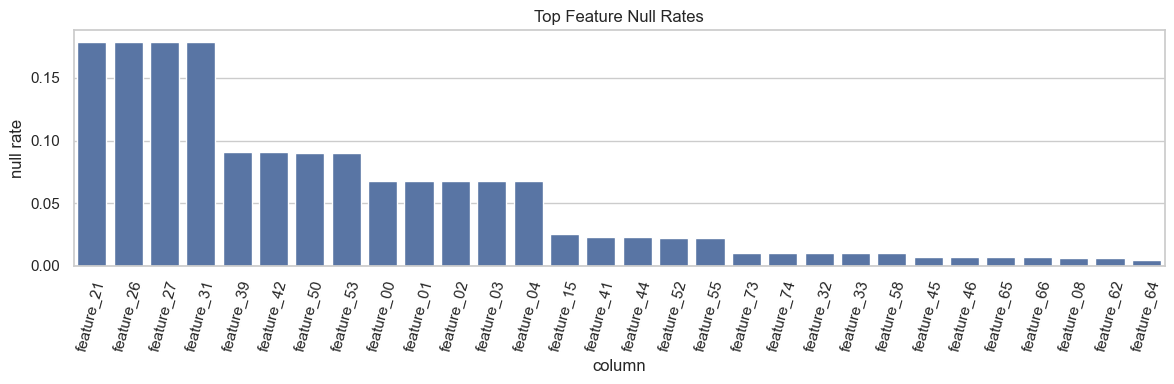

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_nulls = null_rates[null_rates["column"].str.startswith("feature_")].copy()
sns.barplot(data=plot_nulls.head(30), x="column", y="null_rate", ax=ax)
ax.set_title("Top Feature Null Rates")
ax.set_ylabel("null rate")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()

In [13]:
features_meta = pd.read_csv(FEATURES_META)
responders_meta = pd.read_csv(RESPONDERS_META)

feature_tag_cols = [col for col in features_meta.columns if col.startswith("tag_")]
features_meta["n_tags"] = features_meta[feature_tag_cols].sum(axis=1)

feature_profile = (
    features_meta
    .merge(null_rates, left_on="feature", right_on="column", how="left")
    .drop(columns=["column"])
    .sort_values("null_rate", ascending=False)
)

display(feature_profile.head(25))
display(responders_meta)

,feature,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16,n_tags,null_count,null_rate
21,feature_21,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,8435985,0.179004
31,feature_31,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,8435985,0.179004
27,feature_27,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,8435985,0.179004
26,feature_26,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,8435985,0.179004
39,feature_39,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,True,False,4,4300649,0.091256
42,feature_42,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,4,4300649,0.091256
53,feature_53,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,3,4254098,0.090268
50,feature_50,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,3,4254098,0.090268
1,feature_01,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,True,4,3182052,0.067520
0,feature_00,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,3,3182052,0.067520


,responder,tag_0,tag_1,tag_2,tag_3,tag_4
0,responder_0,True,False,True,False,False
1,responder_1,True,False,False,True,False
2,responder_2,True,True,False,False,False
3,responder_3,False,False,True,False,True
4,responder_4,False,False,False,True,True
5,responder_5,False,True,False,False,True
6,responder_6,False,False,True,False,False
7,responder_7,False,False,False,True,False
8,responder_8,False,True,False,False,False


## Responder And Feature Relationships

These are exploratory correlations only. In this kind of financial data, simple linear correlations are expected to be small and unstable, so treat them as hints for grouping and sanity checks rather than feature selection by themselves.

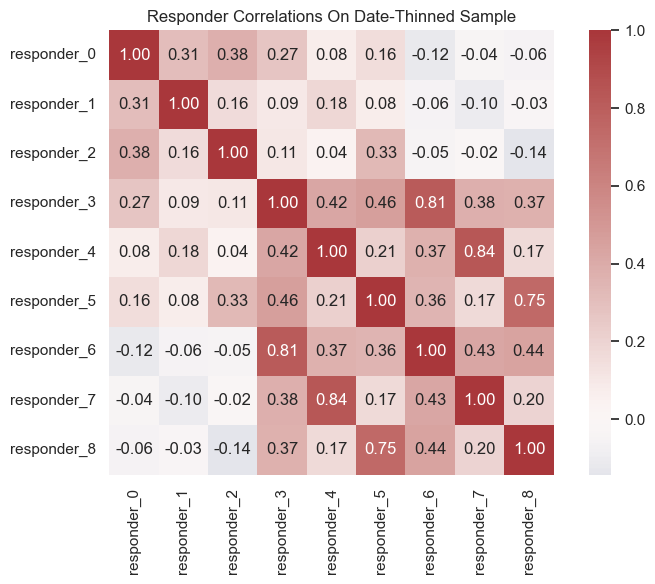

In [14]:
responder_corr = sample_pd[RESPONDER_COLS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(responder_corr, cmap="vlag", center=0, annot=True, fmt=".2f", square=True)
plt.title("Responder Correlations On Date-Thinned Sample")
plt.tight_layout()

In [15]:
feature_corrs = []
for feature in FEATURE_COLS:
    corr = sample.select(pl.corr(feature, TARGET)).item()
    feature_corrs.append(
        {
            "feature": feature,
            "corr_with_target": corr,
            "abs_corr_with_target": abs(corr) if corr is not None else None,
        }
    )

feature_corr_df = (
    pd.DataFrame(feature_corrs)
    .sort_values("abs_corr_with_target", ascending=False)
    .merge(features_meta, on="feature", how="left")
)

feature_corr_df.head(20)

,feature,corr_with_target,abs_corr_with_target,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16,n_tags
0,feature_06,-0.047906,0.047906,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,3
1,feature_07,-0.040735,0.040735,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,3
2,feature_04,-0.026818,0.026818,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,True,4
3,feature_05,-0.025750,0.025750,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,3
4,feature_36,-0.025261,0.025261,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,3
5,feature_45,-0.021446,0.021446,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,3
6,feature_56,-0.020370,0.020370,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,2
7,feature_08,0.017013,0.017013,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,2
8,feature_19,-0.017005,0.017005,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,2
9,feature_51,0.015151,0.015151,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,3


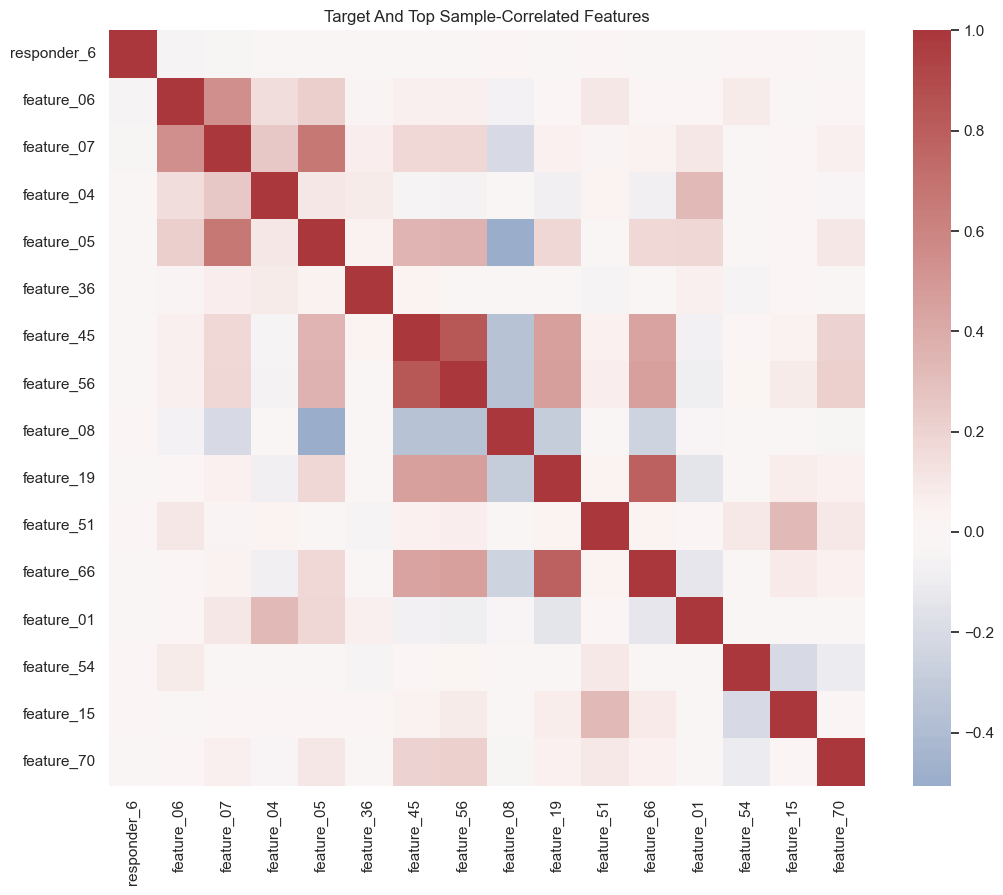

In [16]:
top_features = feature_corr_df["feature"].head(15).tolist()
cols_for_heatmap = [TARGET, *top_features]

corr_top = sample_pd[cols_for_heatmap].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_top, cmap="vlag", center=0, square=True)
plt.title("Target And Top Sample-Correlated Features")
plt.tight_layout()

## Symbol Coverage

Symbols do not appear uniformly across all dates. This matters for validation and for feature engineering that uses lagged values by symbol.

In [17]:
symbol_summary = (
    train_lf
    .group_by("symbol_id")
    .agg(
        pl.len().alias("rows"),
        pl.col("date_id").min().alias("first_date_id"),
        pl.col("date_id").max().alias("last_date_id"),
        pl.col("date_id").n_unique().alias("n_dates"),
        pl.col(TARGET).mean().alias("target_mean"),
        pl.col(TARGET).std().alias("target_std"),
        pl.col("weight").mean().alias("weight_mean"),
    )
    .sort("rows", descending=True)
    .collect()
    .to_pandas()
)

symbol_summary

,symbol_id,rows,first_date_id,last_date_id,n_dates,target_mean,target_std,weight_mean
0,19,1550501,0,1698,1684,0.000418,0.811708,4.487421
1,7,1546272,0,1698,1680,-0.001084,0.836084,2.383477
2,1,1543979,0,1698,1678,-0.003720,0.712762,3.678803
3,16,1538290,0,1698,1672,0.000831,0.792578,2.189813
4,9,1525333,0,1698,1658,-0.024898,0.819305,2.028212
5,10,1515692,0,1698,1643,0.002250,0.827172,1.647775
6,12,1514621,3,1698,1643,-0.009001,0.931444,2.196132
7,33,1508099,0,1698,1637,-0.009958,0.816656,1.758066
8,13,1507964,1,1698,1636,-0.001046,0.877636,2.806710
9,2,1484398,1,1698,1606,-0.000269,0.895544,1.835261


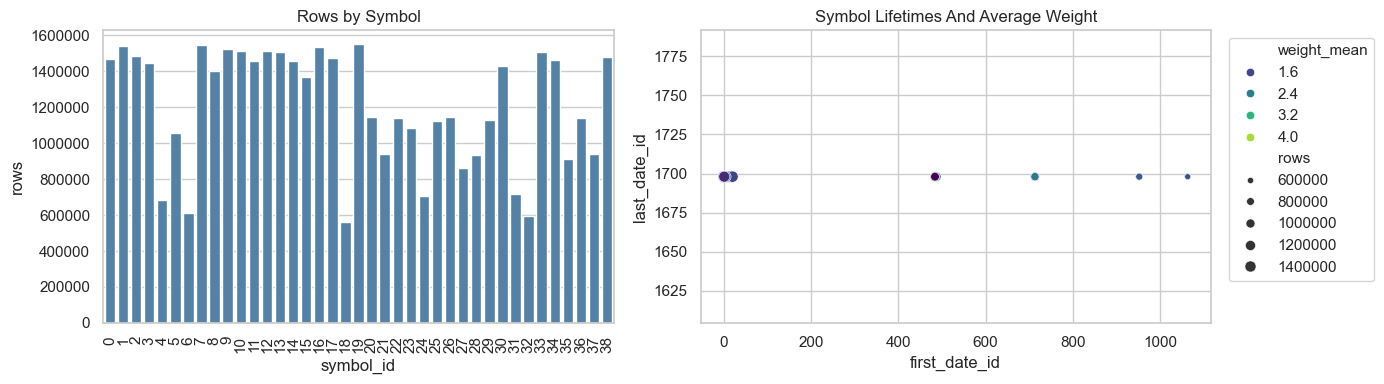

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=symbol_summary, x="symbol_id", y="rows", ax=axes[0], color="steelblue")
axes[0].set_title("Rows by Symbol")
axes[0].tick_params(axis="x", rotation=90)
axes[0].ticklabel_format(axis="y", style="plain")

sns.scatterplot(
    data=symbol_summary,
    x="first_date_id",
    y="last_date_id",
    size="rows",
    hue="weight_mean",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Symbol Lifetimes And Average Weight")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

## Metric Sanity Check

The competition metric is weighted zero-mean R-squared for `responder_6`:

$$R^2 = 1 - \frac{\sum_i w_i(y_i - \hat{y}_i)^2}{\sum_i w_i y_i^2}$$

A prediction of exactly zero scores 0 by construction. Constant non-zero predictions can score negative, so model validation should compare against the zero baseline.

In [23]:
def weighted_zero_mean_r2(y_true, y_pred, weight):
    numerator = (weight * (y_true - y_pred) ** 2).sum()
    denominator = (weight * y_true**2).sum()
    return 1 - numerator / denominator

sample_y = sample_pd[TARGET]
sample_w = sample_pd["weight"]
weighted_mean_prediction = (sample_w * sample_y).sum() / sample_w.sum()

baseline_scores = pd.DataFrame(
    [
        {
            "prediction": "zero",
            "constant_value": 0.0,
            "weighted_zero_mean_r2": weighted_zero_mean_r2(sample_y, 0.0, sample_w),
        },
        {
            "prediction": "sample weighted mean",
            "constant_value": weighted_mean_prediction,
            "weighted_zero_mean_r2": weighted_zero_mean_r2(sample_y, weighted_mean_prediction, sample_w),
        },
    ]
)

baseline_scores

,prediction,constant_value,weighted_zero_mean_r2
0,zero,0.00000,0.000000
1,sample weighted mean,-0.00592,0.000049


## Working Takeaways

- Use chronological validation, likely by holding out the last partition or the last several `date_id` ranges. Random splits will leak time-regime information.
- Keep the zero prediction baseline visible because the official score is zero-mean weighted R-squared.
- Treat `symbol_id` as non-stationary coverage: new symbols appear over time, and Kaggle notes future test data may include unseen symbols.
- Missingness appears in repeated feature groups. Simple models should start with explicit null handling; tree models may handle this naturally, while linear/neural models need imputation and missing indicators.
- Linear feature-target correlations are tiny, which is normal for this domain. More useful next steps are lag features, per-symbol rolling summaries, and validation grouped by future dates.

## Lags Parquet Coverage Check

Check whether `data/lags.parquet/` covers the full training horizon or only a subset.

Expectation if full coverage: lag dates should roughly span train dates shifted by one day (except the first train day), with substantial row counts per date.

In [24]:
LAGS_DIR = DATA_DIR / "lags.parquet"
LAGS_GLOB = str(LAGS_DIR / "date_id=*" / "*.parquet")

lags_files = sorted(LAGS_DIR.glob("date_id=*/part-*.parquet"))
print(f"lags files: {len(lags_files)}")
for p in lags_files[:10]:
    print("-", p.parent.name, p.name)

lags_lf = pl.scan_parquet(LAGS_GLOB)

train_date_stats = train_lf.select(
    pl.col("date_id").min().alias("train_min_date"),
    pl.col("date_id").max().alias("train_max_date"),
    pl.col("date_id").n_unique().alias("train_n_dates"),
).collect()

lags_date_stats = lags_lf.select(
    pl.len().alias("lags_rows"),
    pl.col("date_id").min().alias("lags_min_date"),
    pl.col("date_id").max().alias("lags_max_date"),
    pl.col("date_id").n_unique().alias("lags_n_dates"),
    pl.col("symbol_id").n_unique().alias("lags_n_symbols"),
).collect()

display(train_date_stats.to_pandas())
display(lags_date_stats.to_pandas())

lags_by_date = lags_lf.group_by("date_id").agg(
    pl.len().alias("rows"),
    pl.col("symbol_id").n_unique().alias("n_symbols"),
    pl.col("time_id").n_unique().alias("n_time_ids"),
).sort("date_id").collect().to_pandas()

display(lags_by_date)

train_dates = set(train_lf.select(pl.col("date_id").unique()).collect()["date_id"].to_list())
lags_dates = set(lags_lf.select(pl.col("date_id").unique()).collect()["date_id"].to_list())
expected_lag_dates = {d for d in train_dates if d > min(train_dates)}

missing_lag_dates = sorted(expected_lag_dates - lags_dates)
extra_lag_dates = sorted(lags_dates - expected_lag_dates)

print(f"expected lag dates (from train, excluding first day): {len(expected_lag_dates)}")
print(f"observed lag dates: {len(lags_dates)}")
print(f"missing lag dates: {len(missing_lag_dates)}")
print(f"extra lag dates: {len(extra_lag_dates)}")
print("first 10 missing lag dates:", missing_lag_dates[:10])

lags files: 1
- date_id=0 part-0.parquet


,train_min_date,train_max_date,train_n_dates
0,0,1698,1699


,lags_rows,lags_min_date,lags_max_date,lags_n_dates,lags_n_symbols
0,39,0,0,1,39


,date_id,rows,n_symbols,n_time_ids
0,0,39,39,1


expected lag dates (from train, excluding first day): 1698
observed lag dates: 1
missing lag dates: 1698
extra lag dates: 1
first 10 missing lag dates: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


If this output shows only `date_id=0` with 39 rows and one `time_id`, then `lags.parquet` here is just a tiny mock/sample file and does **not** contain lag responders for the full train dataset.

That is consistent with Kaggle packaging examples for local API structure checks rather than full historical lag materialization.